# Importing Libraries

In [1]:
 
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
 
from pathlib import Path
from sklearn.metrics import (
    accuracy_score, log_loss, brier_score_loss,
    confusion_matrix, classification_report,
    roc_curve, auc
)
from sklearn.calibration import calibration_curve

import warnings
warnings.filterwarnings("ignore")

In [2]:
 
base_dir        = Path('../artifacts')
PREDICTIONS_DIR = base_dir / 'predictions'
METRICS_DIR     = base_dir / 'metrics'
FIGURE_DIR      = base_dir / 'figures'
REPORTS_DIR     = base_dir / 'reports'
 
for path in [FIGURE_DIR, METRICS_DIR, REPORTS_DIR]:
    path.mkdir(parents=True, exist_ok=True)
 

In [3]:
poisson_preds  = pd.read_csv(f'{PREDICTIONS_DIR}/poisson_valid_preds.csv',
                              parse_dates=['date'])
dc_preds       = pd.read_csv(f'{PREDICTIONS_DIR}/dc_valid_preds.csv',
                              parse_dates=['date'])
xgb_preds      = pd.read_csv(f'{PREDICTIONS_DIR}/xgb_valid_preds.csv',
                              parse_dates=['date'])
ensemble_preds = pd.read_csv(f'{PREDICTIONS_DIR}/ensemble_valid_preds.csv',
                              parse_dates=['date'])
 
# Load thresholds
with open(f'{METRICS_DIR}/poisson_threshold.json')  as f: p_thresh   = json.load(f)['draw_threshold']
with open(f'{METRICS_DIR}/dc_threshold.json')        as f: dc_thresh  = json.load(f)['draw_threshold']
with open(f'{METRICS_DIR}/xgb_threshold.json')       as f: xgb_thresh = json.load(f)['draw_threshold']
with open(f'{METRICS_DIR}/ensemble_config.json')     as f: ens_cfg    = json.load(f)
 
ens_thresh = ens_cfg['draw_threshold']
 
y_true = poisson_preds['result'].values   # 0=HomeWin, 1=Draw, 2=AwayWin
 
print(f"Validation set: {len(y_true):,} matches")
print(f"Thresholds — Poisson:{p_thresh}  DC:{dc_thresh}  XGB:{xgb_thresh}  Ensemble:{ens_thresh}")

Validation set: 1,776 matches
Thresholds — Poisson:0.28  DC:0.3  XGB:0.31  Ensemble:0.4000000000000002


# Model Registry

In [4]:
MODELS = {
    'Poisson': {
        'preds':     poisson_preds,
        'threshold': p_thresh,
        'color':     'steelblue',
    },
    'Dixon-Coles': {
        'preds':     dc_preds,
        'threshold': dc_thresh,
        'color':     'tomato',
    },
    'XGBoost': {
        'preds':     xgb_preds,
        'threshold': xgb_thresh,
        'color':     'forestgreen',
    },
    'Ensemble': {
        'preds':     ensemble_preds,
        'threshold': ens_thresh,
        'color':     'darkorange',
    },
}
 

# Helper Functions 

In [5]:
 
def predict_outcome(p_home, p_draw, p_away, threshold):
    if p_draw >= threshold:
        return 1
    return 0 if p_home >= p_away else 2
 
 
def get_predictions(model_dict):
    preds = model_dict['preds']
    thresh = model_dict['threshold']
    pred_results = [
        predict_outcome(r['prob_home_win'], r['prob_draw'], r['prob_away_win'], thresh)
        for _, r in preds.iterrows()
    ]
    prob_matrix = preds[['prob_home_win', 'prob_draw', 'prob_away_win']].values
    return np.array(pred_results), prob_matrix
 
 
def compute_metrics(model_name, model_dict, y_true):
    pred_results, prob_matrix = get_predictions(model_dict)
    acc    = accuracy_score(y_true, pred_results)
    ll     = log_loss(y_true, prob_matrix, labels=[0, 1, 2])
    brier  = np.mean([
        brier_score_loss((y_true == c).astype(int), prob_matrix[:, c])
        for c in range(3)
    ])
 
    # Per-class metrics
    report = classification_report(
        y_true, pred_results,
        target_names=['HomeWin', 'Draw', 'AwayWin'],
        output_dict=True, zero_division=0
    )
 
    return {
        'model':          model_name,
        'accuracy':       acc,
        'log_loss':       ll,
        'brier_score':    brier,
        'hw_f1':          report['HomeWin']['f1-score'],
        'draw_f1':        report['Draw']['f1-score'],
        'aw_f1':          report['AwayWin']['f1-score'],
        'draw_recall':    report['Draw']['recall'],
        'draw_precision': report['Draw']['precision'],
        'pred_results':   pred_results,
        'prob_matrix':    prob_matrix,
    }

In [6]:
all_metrics = {}
for name, model_dict in MODELS.items():
    all_metrics[name] = compute_metrics(name, model_dict, y_true)
    print(f"{name:15s} → Acc: {all_metrics[name]['accuracy']:.2%}  "
          f"LogLoss: {all_metrics[name]['log_loss']:.4f}  "
          f"Brier: {all_metrics[name]['brier_score']:.4f}  "
          f"DrawF1: {all_metrics[name]['draw_f1']:.3f}")
 

Poisson         → Acc: 81.02%  LogLoss: 0.6475  Brier: 0.1184  DrawF1: 0.571
Dixon-Coles     → Acc: 81.25%  LogLoss: 0.6320  Brier: 0.1167  DrawF1: 0.624
XGBoost         → Acc: 61.26%  LogLoss: 0.8563  Brier: 0.1672  DrawF1: 0.059
Ensemble        → Acc: 91.89%  LogLoss: 0.2136  Brier: 0.0402  DrawF1: 0.842


# Summary 

In [7]:
summary = pd.DataFrame([
    {
        'Model':          m['model'],
        'Accuracy':       f"{m['accuracy']:.2%}",
        'Log Loss':       f"{m['log_loss']:.4f}",
        'Brier Score':    f"{m['brier_score']:.4f}",
        'HomeWin F1':     f"{m['hw_f1']:.3f}",
        'Draw F1':        f"{m['draw_f1']:.3f}",
        'AwayWin F1':     f"{m['aw_f1']:.3f}",
        'Draw Recall':    f"{m['draw_recall']:.3f}",
        'Draw Precision': f"{m['draw_precision']:.3f}",
    }
    for m in all_metrics.values()
])
 

print(summary.to_string(index=False))

      Model Accuracy Log Loss Brier Score HomeWin F1 Draw F1 AwayWin F1 Draw Recall Draw Precision
    Poisson   81.02%   0.6475      0.1184      0.865   0.571      0.886       0.508          0.650
Dixon-Coles   81.25%   0.6320      0.1167      0.874   0.624      0.868       0.639          0.610
    XGBoost   61.26%   0.8563      0.1672      0.728   0.059      0.635       0.031          0.419
   Ensemble   91.89%   0.2136      0.0402      0.953   0.842      0.932       0.915          0.779


# Visualizations 

In [8]:
MODEL_NAMES   = list(all_metrics.keys())
MODEL_COLORS  = [MODELS[n]['color'] for n in MODEL_NAMES]
 
 


## Accuracy Comparison Bar Chart

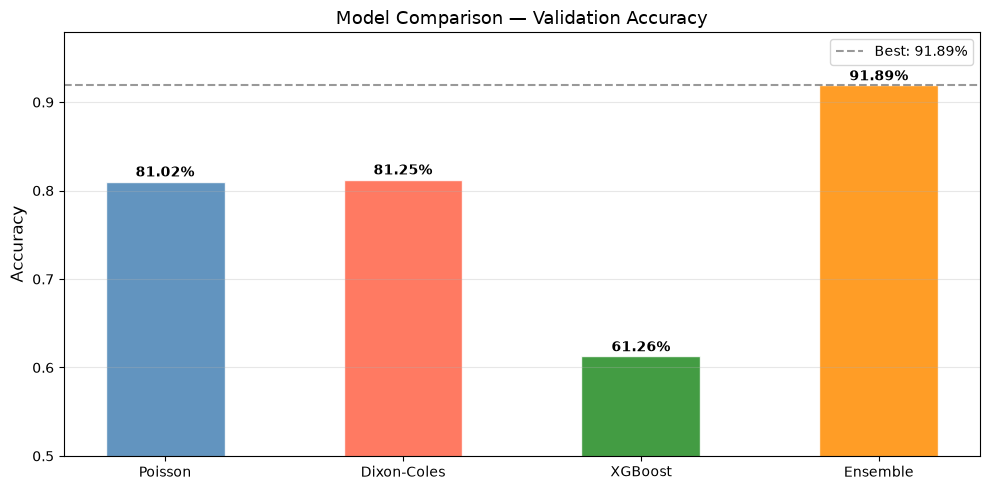

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
 
accs = [all_metrics[n]['accuracy'] for n in MODEL_NAMES]
bars = ax.bar(MODEL_NAMES, accs, color=MODEL_COLORS, alpha=0.85, edgecolor='white', width=0.5)
 
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{acc:.2%}', ha='center', va='bottom', fontsize=10, fontweight='bold')
 
ax.set_ylim(0.5, min(1.0, max(accs) + 0.06))
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Model Comparison — Validation Accuracy', fontsize=13)
ax.axhline(max(accs), color='black', linestyle='--', alpha=0.4, label=f'Best: {max(accs):.2%}')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/comparison_accuracy.png', dpi=150)
plt.show()

## Multi-Metric Radar / Bar Grouped

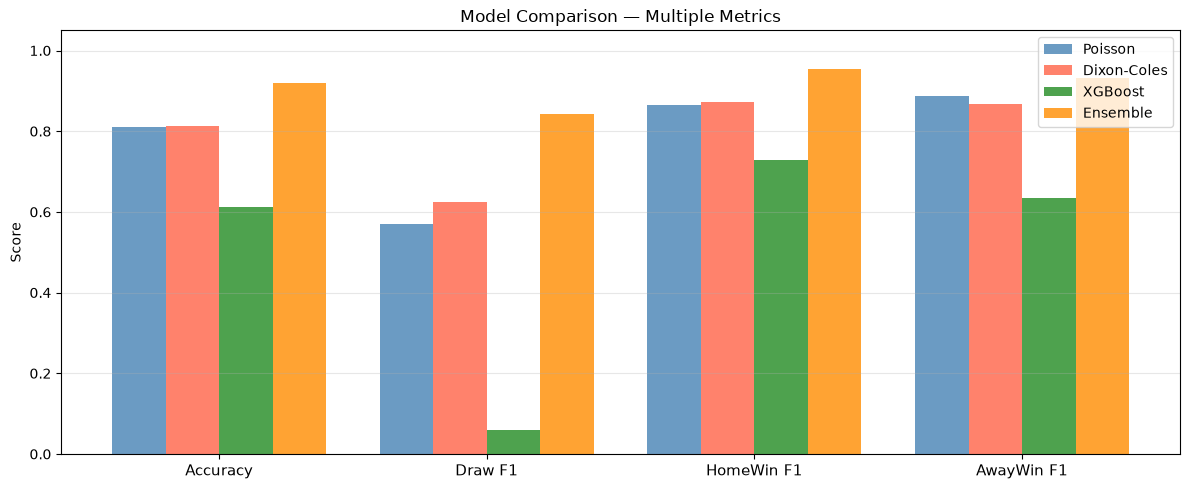

In [10]:
metrics_to_plot = ['accuracy', 'draw_f1', 'hw_f1', 'aw_f1']
metric_labels   = ['Accuracy', 'Draw F1', 'HomeWin F1', 'AwayWin F1']
 
x     = np.arange(len(metrics_to_plot))
width = 0.2
 
fig, ax = plt.subplots(figsize=(12, 5))
 
for i, (name, color) in enumerate(zip(MODEL_NAMES, MODEL_COLORS)):
    vals = [all_metrics[name][m] for m in metrics_to_plot]
    bars = ax.bar(x + i * width, vals, width, label=name, color=color, alpha=0.8)
 
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metric_labels, fontsize=11)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — Multiple Metrics')
ax.legend()
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/comparison_multi_metric.png', dpi=150)
plt.show()

## Draw Performance Comparison

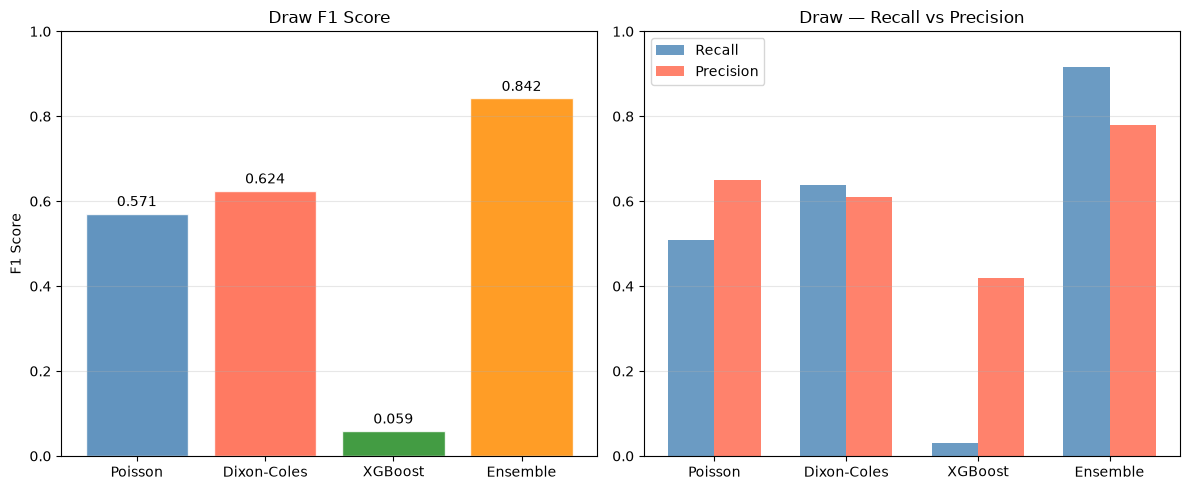

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
 
# Draw F1
draw_f1s = [all_metrics[n]['draw_f1'] for n in MODEL_NAMES]
axes[0].bar(MODEL_NAMES, draw_f1s, color=MODEL_COLORS, alpha=0.85, edgecolor='white')
for i, v in enumerate(draw_f1s):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontsize=10)
axes[0].set_title('Draw F1 Score')
axes[0].set_ylabel('F1 Score')
axes[0].set_ylim(0, 1.0)
axes[0].grid(axis='y', alpha=0.3)
 
# Draw Recall vs Precision
draw_recalls    = [all_metrics[n]['draw_recall']    for n in MODEL_NAMES]
draw_precisions = [all_metrics[n]['draw_precision'] for n in MODEL_NAMES]
 
x     = np.arange(len(MODEL_NAMES))
width = 0.35
axes[1].bar(x - width/2, draw_recalls,    width, label='Recall',    color='steelblue', alpha=0.8)
axes[1].bar(x + width/2, draw_precisions, width, label='Precision', color='tomato',    alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(MODEL_NAMES)
axes[1].set_title('Draw — Recall vs Precision')
axes[1].set_ylim(0, 1.0)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)
 
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/comparison_draw_performance.png', dpi=150)
plt.show()
 

## Confusion Matrices Side by Side 

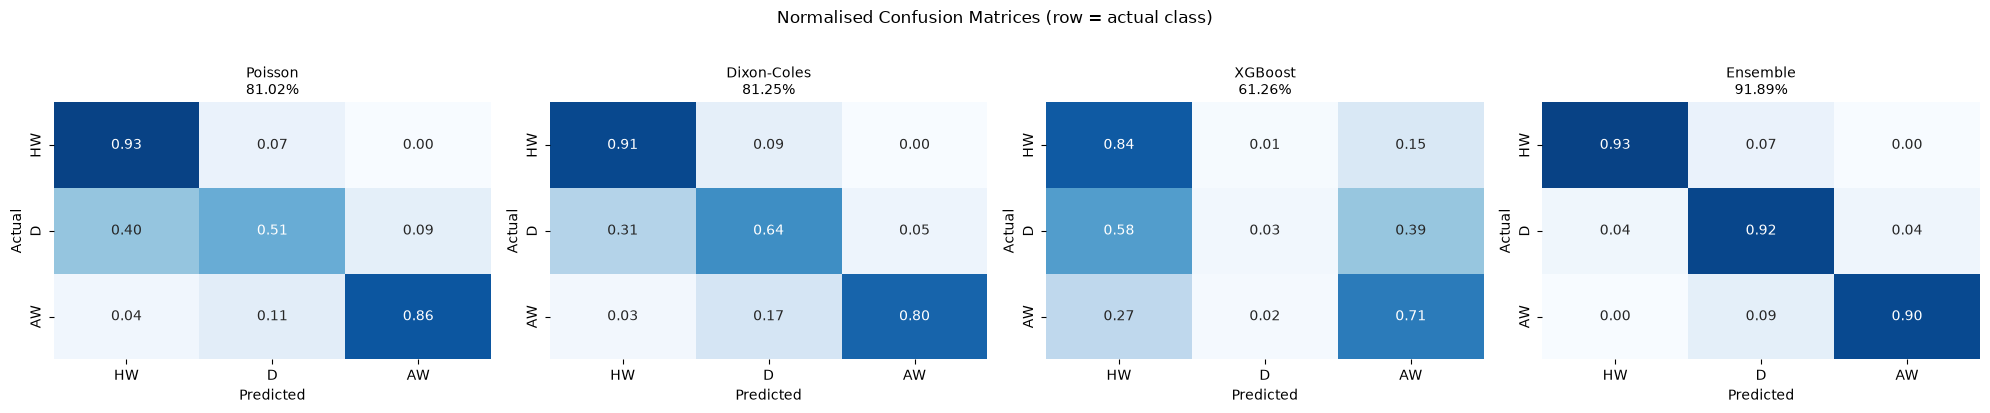

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
 
for ax, (name, color) in zip(axes, zip(MODEL_NAMES, MODEL_COLORS)):
    cm = confusion_matrix(y_true, all_metrics[name]['pred_results'], labels=[0, 1, 2])
    # Normalise by row (recall per class)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(
        cm_norm, annot=True, fmt='.2f', cmap='Blues',
        xticklabels=['HW', 'D', 'AW'],
        yticklabels=['HW', 'D', 'AW'],
        ax=ax, cbar=False, vmin=0, vmax=1
    )
    acc = all_metrics[name]['accuracy']
    ax.set_title(f"{name}\n{acc:.2%}", fontsize=10)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
 
plt.suptitle('Normalised Confusion Matrices (row = actual class)', y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/comparison_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## Log Loss & Brier Score Comparison

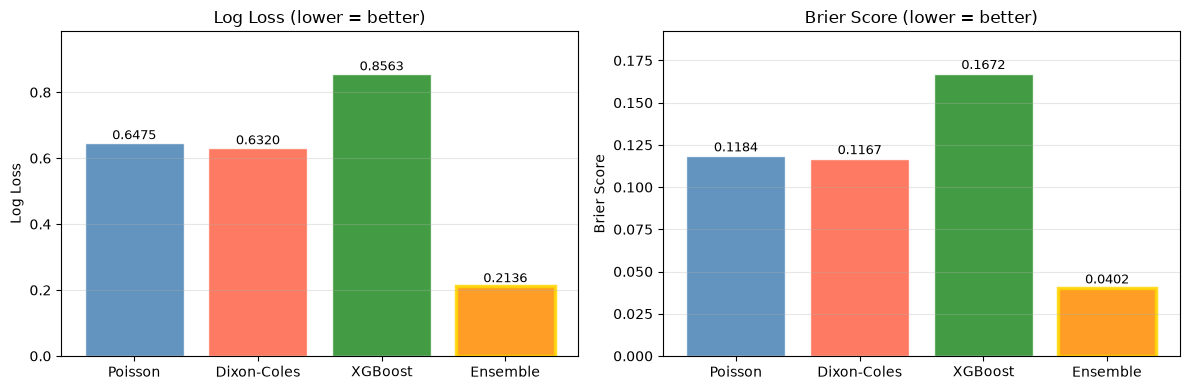

In [13]:
 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
 
lls     = [all_metrics[n]['log_loss']    for n in MODEL_NAMES]
briers  = [all_metrics[n]['brier_score'] for n in MODEL_NAMES]
 
for ax, vals, title, ylabel in [
    (axes[0], lls,    'Log Loss (lower = better)',    'Log Loss'),
    (axes[1], briers, 'Brier Score (lower = better)', 'Brier Score'),
]:
    bars = ax.bar(MODEL_NAMES, vals, color=MODEL_COLORS, alpha=0.85, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{v:.4f}', ha='center', va='bottom', fontsize=9)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, max(vals) * 1.15)
    ax.grid(axis='y', alpha=0.3)
    # Highlight best (lowest)
    best_idx = np.argmin(vals)
    bars[best_idx].set_edgecolor('gold')
    bars[best_idx].set_linewidth(2.5)
 
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/comparison_log_loss_brier.png', dpi=150)
plt.show()

## Calibration Curves 

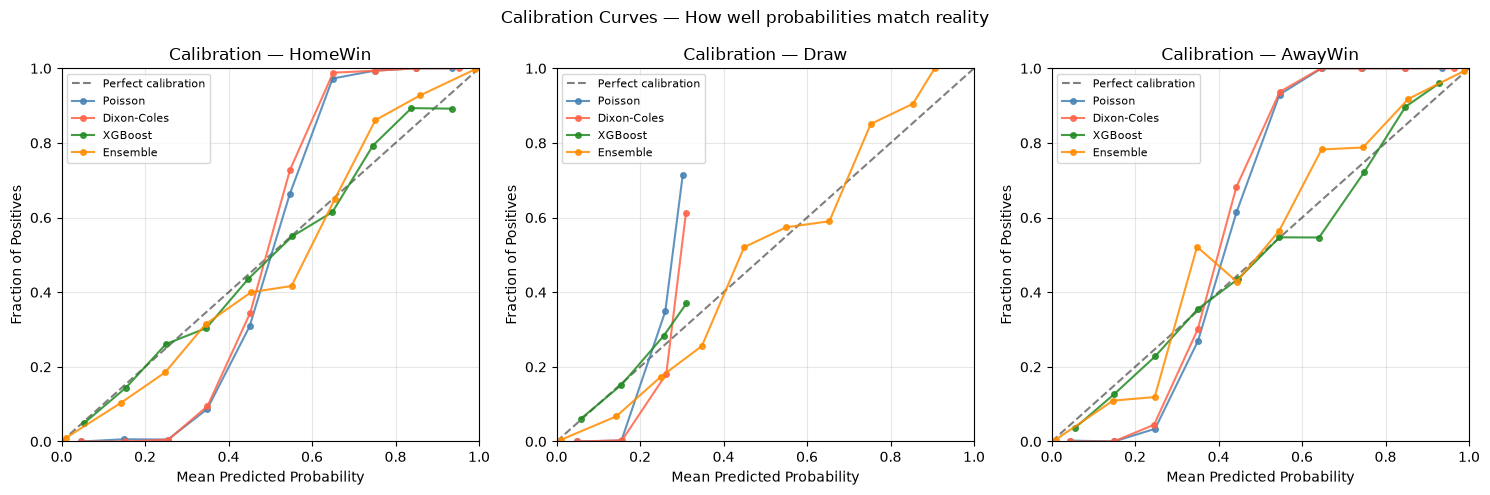

In [14]:
CLASS_NAMES = ['HomeWin', 'Draw', 'AwayWin']
 
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
 
for c, (ax, class_name) in enumerate(zip(axes, CLASS_NAMES)):
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect calibration')
 
    for name, color in zip(MODEL_NAMES, MODEL_COLORS):
        prob_col  = all_metrics[name]['prob_matrix'][:, c]
        y_binary  = (y_true == c).astype(int)
 
        try:
            fraction_pos, mean_pred = calibration_curve(
                y_binary, prob_col, n_bins=10, strategy='uniform'
            )
            ax.plot(mean_pred, fraction_pos, marker='o', markersize=4,
                    color=color, label=name, alpha=0.85)
        except Exception:
            pass
 
    ax.set_title(f'Calibration — {class_name}')
    ax.set_xlabel('Mean Predicted Probability')
    ax.set_ylabel('Fraction of Positives')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
 
plt.suptitle('Calibration Curves — How well probabilities match reality', fontsize=12)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/comparison_calibration.png', dpi=150)
plt.show()

##  ROC Curves (One-vs-Rest per class)

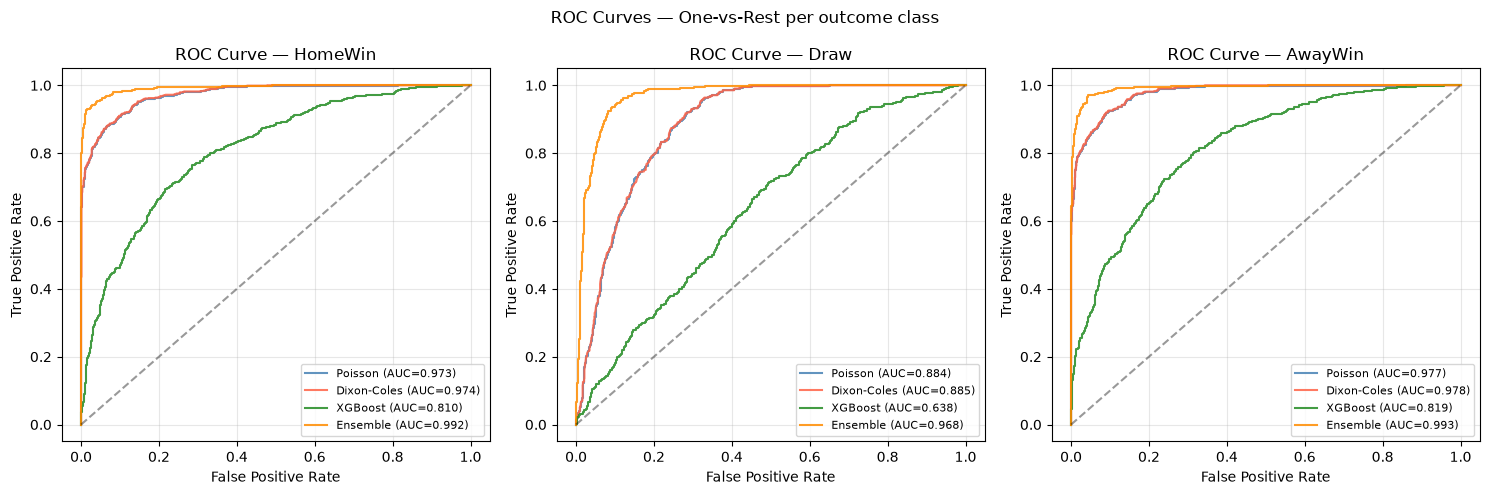

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
 
for c, (ax, class_name) in enumerate(zip(axes, CLASS_NAMES)):
    y_binary = (y_true == c).astype(int)
 
    for name, color in zip(MODEL_NAMES, MODEL_COLORS):
        prob_col = all_metrics[name]['prob_matrix'][:, c]
        fpr, tpr, _ = roc_curve(y_binary, prob_col)
        roc_auc     = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=color, alpha=0.85,
                label=f'{name} (AUC={roc_auc:.3f})')
 
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
    ax.set_title(f'ROC Curve — {class_name}')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
 
plt.suptitle('ROC Curves — One-vs-Rest per outcome class', fontsize=12)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/comparison_roc_curves.png', dpi=150)
plt.show()
 

## Predicted Draw Rate vs Actual

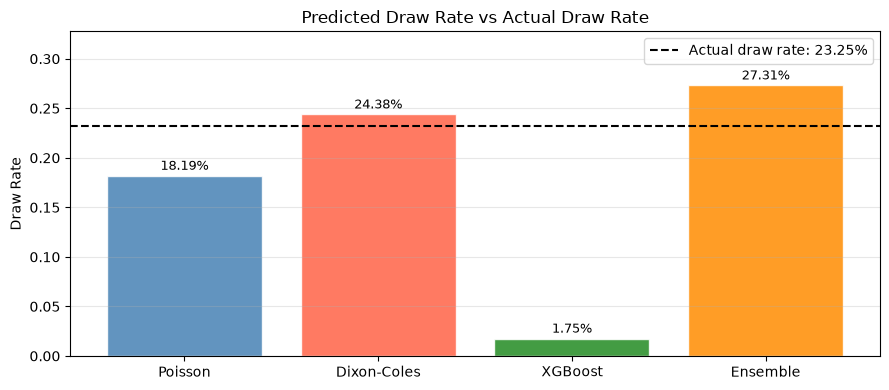

In [16]:
actual_draw_rate = (y_true == 1).mean()
 
fig, ax = plt.subplots(figsize=(9, 4))
 
pred_draw_rates = []
for name in MODEL_NAMES:
    pdr = (all_metrics[name]['pred_results'] == 1).mean()
    pred_draw_rates.append(pdr)
 
bars = ax.bar(MODEL_NAMES, pred_draw_rates, color=MODEL_COLORS, alpha=0.85, edgecolor='white')
ax.axhline(actual_draw_rate, color='black', linestyle='--',
           label=f'Actual draw rate: {actual_draw_rate:.2%}')
for bar, v in zip(bars, pred_draw_rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{v:.2%}', ha='center', va='bottom', fontsize=9)
ax.set_title('Predicted Draw Rate vs Actual Draw Rate')
ax.set_ylabel('Draw Rate')
ax.set_ylim(0, max(pred_draw_rates + [actual_draw_rate]) * 1.2)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/comparison_draw_rate.png', dpi=150)
plt.show()

## Per-Confidence Accuracy (reliability diagram)

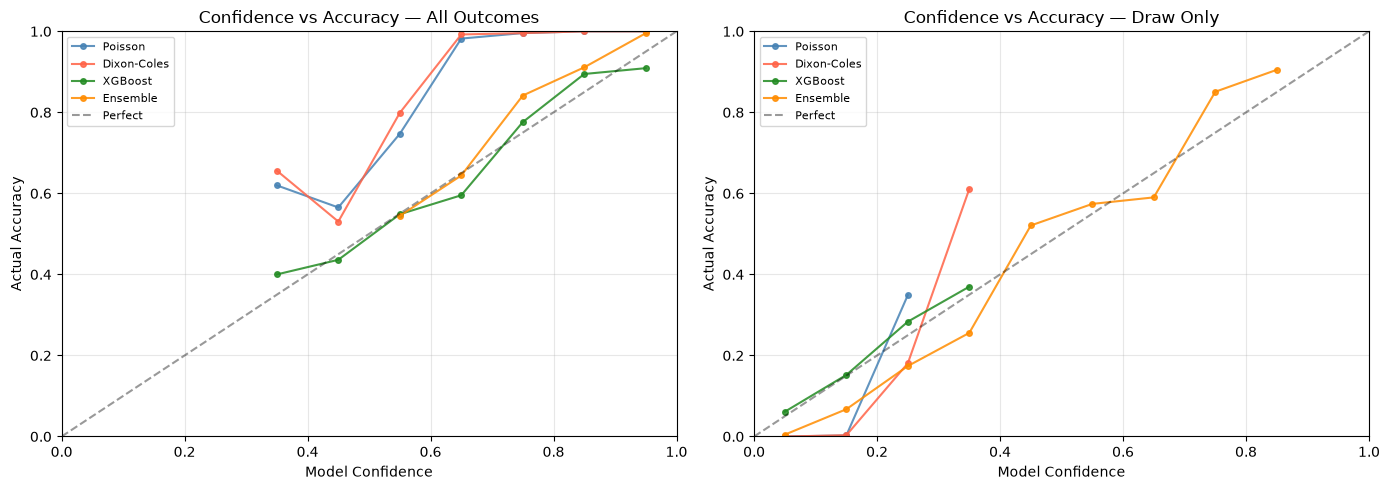

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
for ax, target_class, class_label in [
    (axes[0], None,  'All Outcomes'),
    (axes[1], 1,     'Draw Only'),
]:
    for name, color in zip(MODEL_NAMES, MODEL_COLORS):
        prob_matrix  = all_metrics[name]['prob_matrix']
        pred_results = all_metrics[name]['pred_results']
 
        if target_class is None:
            # Max probability = confidence
            confidence = prob_matrix.max(axis=1)
            correct    = (pred_results == y_true).astype(int)
        else:
            confidence = prob_matrix[:, target_class]
            correct    = (y_true == target_class).astype(int)
 
        # Bin by confidence
        bins      = np.linspace(0, 1, 11)
        bin_acc   = []
        bin_mid   = []
        for lo, hi in zip(bins[:-1], bins[1:]):
            mask = (confidence >= lo) & (confidence < hi)
            if mask.sum() > 10:
                bin_acc.append(correct[mask].mean())
                bin_mid.append((lo + hi) / 2)
 
        ax.plot(bin_mid, bin_acc, marker='o', color=color,
                label=name, alpha=0.85, markersize=4)
 
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Perfect')
    ax.set_title(f'Confidence vs Accuracy — {class_label}')
    ax.set_xlabel('Model Confidence')
    ax.set_ylabel('Actual Accuracy')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
 
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/comparison_confidence_accuracy.png', dpi=150)
plt.show()

## Save Comparison Report

In [18]:
 
report_data = []
for name in MODEL_NAMES:
    m = all_metrics[name]
    report_data.append({
        'model':          name,
        'accuracy':       round(m['accuracy'],    4),
        'log_loss':       round(m['log_loss'],     4),
        'brier_score':    round(m['brier_score'],  4),
        'hw_f1':          round(m['hw_f1'],        4),
        'draw_f1':        round(m['draw_f1'],      4),
        'aw_f1':          round(m['aw_f1'],        4),
        'draw_recall':    round(m['draw_recall'],   4),
        'draw_precision': round(m['draw_precision'], 4),
        'pred_draw_rate': round((m['pred_results'] == 1).mean(), 4),
    })
 
df_report = pd.DataFrame(report_data)
df_report.to_csv(f'{REPORTS_DIR}/model_comparison.csv', index=False)
 
# Best model per metric
print("\n── Best Model per Metric ─────────────────────────────────")
print(f"  Accuracy     : {df_report.loc[df_report['accuracy'].idxmax(), 'model']}"
      f"  ({df_report['accuracy'].max():.2%})")
print(f"  Log Loss     : {df_report.loc[df_report['log_loss'].idxmin(), 'model']}"
      f"  ({df_report['log_loss'].min():.4f})")
print(f"  Brier Score  : {df_report.loc[df_report['brier_score'].idxmin(), 'model']}"
      f"  ({df_report['brier_score'].min():.4f})")
print(f"  Draw F1      : {df_report.loc[df_report['draw_f1'].idxmax(), 'model']}"
      f"  ({df_report['draw_f1'].max():.3f})")
print(f"  Draw Recall  : {df_report.loc[df_report['draw_recall'].idxmax(), 'model']}"
      f"  ({df_report['draw_recall'].max():.3f})")
 
print(f"\nSaved: reports/model_comparison.csv")
print(df_report.to_string(index=False))


── Best Model per Metric ─────────────────────────────────
  Accuracy     : Ensemble  (91.89%)
  Log Loss     : Ensemble  (0.2136)
  Brier Score  : Ensemble  (0.0402)
  Draw F1      : Ensemble  (0.842)
  Draw Recall  : Ensemble  (0.915)

Saved: reports/model_comparison.csv
      model  accuracy  log_loss  brier_score  hw_f1  draw_f1  aw_f1  draw_recall  draw_precision  pred_draw_rate
    Poisson    0.8102    0.6475       0.1184 0.8650   0.5707 0.8863       0.5085          0.6502          0.1819
Dixon-Coles    0.8125    0.6320       0.1167 0.8736   0.6241 0.8675       0.6392          0.6097          0.2438
    XGBoost    0.6126    0.8563       0.1672 0.7280   0.0586 0.6346       0.0315          0.4194          0.0175
   Ensemble    0.9189    0.2136       0.0402 0.9534   0.8419 0.9319       0.9153          0.7794          0.2731
